In [1]:
from pathlib import Path
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.multiclass import OneVsRestClassifier

MODEL_DIR = "random-forest"
MODEL_NAME = "Random Forest"

cwd = Path.cwd()
project_root = Path("..").resolve() if cwd.name == MODEL_DIR else cwd
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from qsar_config import DATA_PATH, RANDOM_SEED
from qsar_common import (
    add_mol_column,
    aggregate_targets_by_fingerprint,
    build_morgan_fingerprints,
    encode_targets,
    load_qsar_dataset,
    stack_features_and_targets,
    to_target_probability_matrix,
)

In [2]:
df = load_qsar_dataset(DATA_PATH)

In [3]:
df = add_mol_column(df, smiles_column="Smiles", mol_column="mol")

In [4]:
FPSIZE = 2048
df = build_morgan_fingerprints(
    df,
    mol_column="mol",
    output_column="fp",
    radius=2,
    n_bits=FPSIZE,
)

In [5]:
df, encoder, target_names = encode_targets(
    df,
    target_column="Target",
    output_column="target_encoded",
)

In [6]:
df_agg = aggregate_targets_by_fingerprint(
    df,
    fp_column="fp",
    encoded_target_column="target_encoded",
    aggregated_target_column="target",
)

In [7]:
x, y = stack_features_and_targets(
    df_agg,
    fp_column="fp",
    target_column="target",
)

In [8]:
kf = MultilabelStratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

In [9]:
auc_per_fold = []

for train_index, test_index in kf.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=50,
            max_depth=None,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )
    )

    model.fit(X_train, y_train)

    y_pred_prob = model.predict_proba(X_test)
    y_pred_prob_matrix = to_target_probability_matrix(
        y_pred_prob,
        n_targets=y.shape[1],
    )

    roc_auc_values = [
        roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
        for i in range(y.shape[1])
    ]

    auc_per_fold.append(roc_auc_values)

auc_per_fold = np.array(auc_per_fold)
mean_auc = np.mean(auc_per_fold, axis=0)
std_auc = np.std(auc_per_fold, axis=0)

print("Mean ROC-AUC per target:", mean_auc)
print("Std ROC-AUC per target:", std_auc)
print("Overall mean ROC-AUC:", np.mean(mean_auc))

Mean ROC-AUC per target: [0.98007119 0.98621247 0.9790167  0.98941545 0.98193759 0.96595279]
Std ROC-AUC per target: [0.00755898 0.00319932 0.00624486 0.00420306 0.01106814 0.01315603]
Overall mean ROC-AUC: 0.9804343629158252


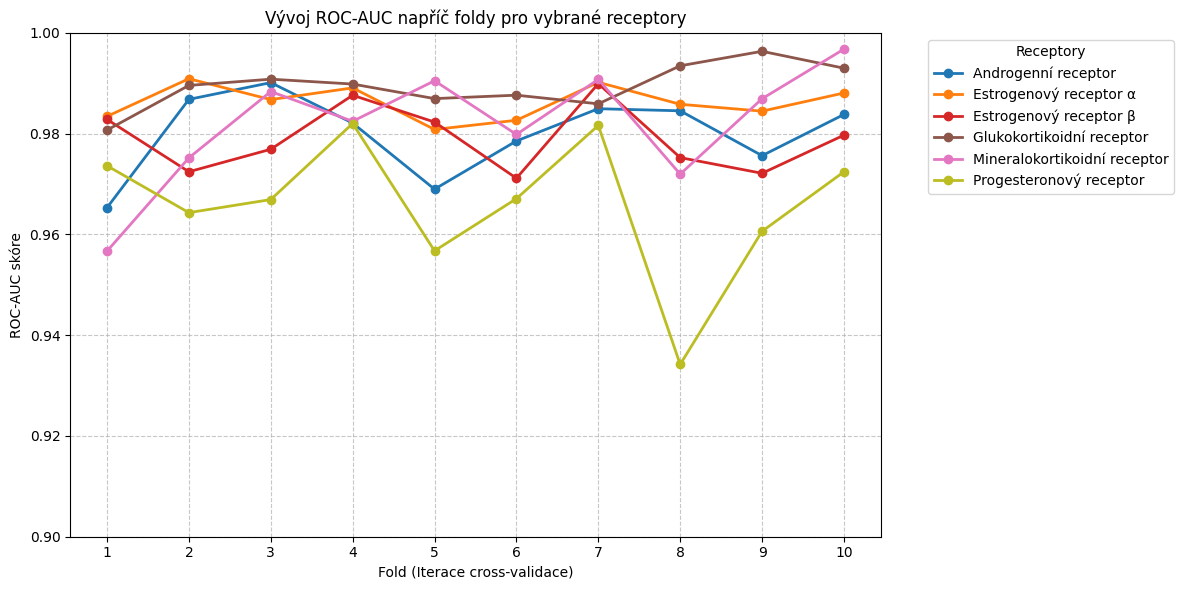

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

num_folds = auc_per_fold.shape[0]
target_indices = [0, 1, 2, 3, 4, 5]

czech_names = {
    "ar": "Androgenní receptor",
    "pr": "Progesteronový receptor",
    "gr": "Glukokortikoidní receptor",
    "mr": "Mineralokortikoidní receptor",
    "era": "Estrogenový receptor α",
    "erb": "Estrogenový receptor β"
}

cmap = matplotlib.colormaps.get_cmap('tab10')
n_targets_total = len(target_names)

fig, ax = plt.subplots(figsize=(12, 6))

x_folds = np.arange(1, num_folds + 1)

for target_idx in target_indices:
    original_name = target_names[target_idx]
    label_name = czech_names.get(original_name.lower(), original_name)

    color = cmap(target_idx / n_targets_total)

    ax.plot(
        x_folds,
        auc_per_fold[:, target_idx],
        label=label_name,
        color=color,
        marker='o',
        linewidth=2
    )

ax.set_xlabel("Fold (Iterace cross-validace)")
ax.set_ylabel("ROC-AUC skóre")
ax.set_title("Vývoj ROC-AUC napříč foldy pro vybrané receptory")

ax.set_ylim(0.9, 1.0)

ax.set_xticks(x_folds)

ax.legend(title="Receptory", bbox_to_anchor=(1.05, 1), loc='upper left')

ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

fig.savefig("images/rf_roc_auc_folds.svg", format="svg", bbox_inches="tight")

plt.show()